In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
archivo = "mnist_split.pkl"

if os.path.exists(archivo):
    print("Cargando dataset guardado...")
    X_train, X_test, y_train, y_test = joblib.load(archivo)

else:
    print("Descargando MNIST...")
    X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=5
    )

    joblib.dump((X_train, X_test, y_train, y_test), archivo)
    print("Dataset guardado")

Cargando dataset guardado...


In [4]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

print("Modelo listo")

Modelo listo


In [ ]:
def detectar_digitos(ruta, etiquetas_reales):
    
    img = cv2.imread(ruta)
    
    if img is None:
        print(f"No se pudo cargar: {ruta}")
        return
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # suavizado
    blur = cv2.GaussianBlur(gray, (7,7), 0)

    # binarización automática
    _, thresh = cv2.threshold(blur, 0, 255,
                             cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # morfología
    kernel = np.ones((3,3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # contornos
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w > 10 and h > 10:
            boxes.append((x,y,w,h))

    # ordenar por filas y columnas
    boxes = sorted(boxes, key=lambda b: (b[1]//50, b[0]))

    predicciones = []

    for (x,y,w,h) in boxes:

        digit = thresh[y:y+h, x:x+w]


        h_d, w_d = digit.shape
        
        if h_d > w_d:
            new_h = 20
            new_w = int(w_d * (20 / h_d))
        else:
            new_w = 20
            new_h = int(h_d * (20 / w_d))

        digit = cv2.resize(digit, (new_w, new_h))

        canvas = np.zeros((28,28), dtype=np.uint8)

        x_offset = (28 - new_w) // 2
        y_offset = (28 - new_h) // 2

        canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = digit

        digit = canvas

        digit = digit.reshape(1, -1)

    
        pred = knn.predict(digit)
        predicciones.append(int(pred[0]))

        # dibujar
        cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(img, str(pred[0]), (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)

   
    min_len = min(len(etiquetas_reales), len(predicciones))
    etiquetas_reales = etiquetas_reales[:min_len]
    predicciones = predicciones[:min_len]

    acc = accuracy_score(etiquetas_reales, predicciones)
    error = (1 - acc) * 100

    print(f"\nImagen: {ruta}")
    print("Reales:       ", etiquetas_reales)
    print("Predicciones: ", predicciones)
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Error: {error:.2f}%")

    # mostrar resultado
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(ruta)
    plt.axis("off")
    plt.show()


Imagen: img/numeros_01.jpg
Reales:        [1, 3, 5, 4, 0]
Predicciones:  [1, 3, 5, 4, 3]
Accuracy: 80.00%
Error: 20.00%


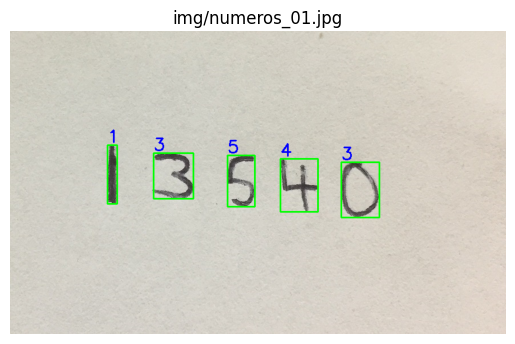


Imagen: img/numeros_02.jpeg
Reales:        [1, 2, 3, 4, 5, 0, 9, 8, 7]
Predicciones:  [1, 3, 4, 5, 0, 4, 8, 1, 8]
Accuracy: 11.11%
Error: 88.89%


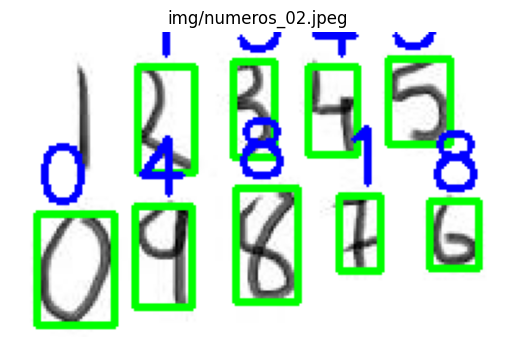


Imagen: img/numeros_03.jpg
Reales:        [1, 2, 3, 4, 5, 6, 7, 8, 9, 0]
Predicciones:  [1, 2, 3, 1, 3, 8, 1, 8, 4, 0]
Accuracy: 50.00%
Error: 50.00%


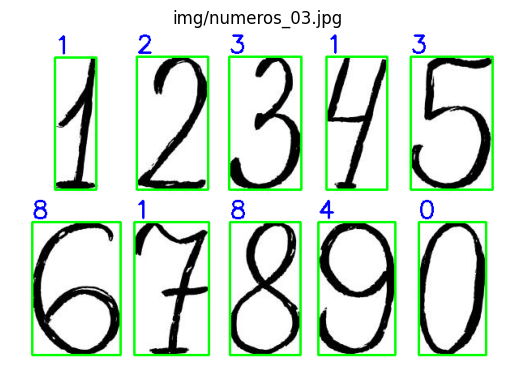

In [6]:
# Imagen 1
detectar_digitos("img/numeros_01.jpg", [1,3,5,4,0])

# Imagen 2
detectar_digitos("img/numeros_02.jpeg", [1,2,3,4,5,0,9,8,7,6])

# Imagen 3
detectar_digitos("img/numeros_03.jpg", [1,2,3,4,5,6,7,8,9,0])